## **Exploratory Data Analysis of Large-Scale Industry Performance Dataset Using Univariate, Bivariate, and Multivariate Statistical Techniques**  

**Name** : Bindu Kale A  
**Dataset** : INDUSTRY.csv  
**Organisation** : NextHikes IT Solutions   
**File Name** : Exploratory_Data_Analysis  
**Submission Date** : June 5 2026  

#### **1. INTRODUCTION** 
* <font size ="3">  Exploratory Data Analysis (EDA) is a statistical approach used to examine, summarize, and understand datasets before applying advanced analytical techniques or machine learning models. 
* It helps identify patterns, trends, relationships, outliers, and distribution characteristics within the data, enabling informed decision-making and accurate interpretation of results. 
* Through univariate, bivariate, and multivariate analyses, this project aims to identify relationships between company size, customer base, profitability, revenue generation, market perception, and regional performance. 
* The findings can support business intelligence, market benchmarking, strategic planning, and future predictive modeling initiatives. </font>   
### **2. Objectives:**  
* <font size ="3"> The primary objective of this analysis is to understand the characteristics of companies across different sectors and evaluate factors that influence business performance. 
* The study involves data preprocessing, descriptive statistical analysis, distribution analysis, outlier detection, correlation analysis, and multivariate comparisons. 
* Both numerical and categorical variables are examined to uncover meaningful business insights and industry trends.   </font>


In [ ]:
# LIBRARIES USED IN EDA:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import seaborn as sns

**Description Of Libraries Used.**  
1. <font size ="3"> Pandas helps manage data by handling and analyzing structured data.  
2. NumPy performs calculations like numerical computations and mathematical operations.  
3. Matplotlib creates basic graphs like bar charts, histograms, and scatter plots to visualize data.  
4. Seaborn makes those graphs more visually appealing and easier to interpret.  
5. The 'from scipy.stats import skew, kurtosis'- imports two essential functions i.e., skew and kurtosis from the SciPy library to measure the shape and distribution of the dataset.  </font>

In [ ]:
# LOADING AND VIEWING THE IMPORTED DATASET:

print("Dataset Preview:")
print("-"*50)
df = pd.read_csv("INDUSTRY.csv")
display (df)

**Dataset Loading Interpretation**
* <font size ="3">  We have imported the data with this we can inspect the first few row and last few rows of the data. This shows a large industry dataset containing information on 15,000 companies operating across 12 different sectors and countries.  
* Companies belong to diverse industries such as Finance, Technology, Retail, Manufacturing, and Healthcare across several countries.  
* The dataset includes companies from different industries and locations, helping us see how businesses operate in various market conditions. It contains both numerical and categorical information, making it easier to analyze performance from different angles.  
* This gives insights on what drives revenue, efficiency, customer behavior, industry trends and business growth.  </font>


#### **3. PREPROCESSING OF THE DATASETS**

In [ ]:
# CONVERSION OF CREATED_DATE TO DATETIME:

if 'created_date' in df.columns:
    df['created_date'] = pd.to_datetime(df['created_date'], format='%d-%m-%Y', errors='coerce')
    print("-> Parsed 'created_date' into datetime format.")

* <font size ="3">  The created_date column was converted into a date format so it can be easily used for analysis, filtering, and time-based calculations.</font>

In [ ]:
# STANDARDISATON OF COLUMN NAMES:

df.columns = df.columns.str.lower().str.strip()

* <font size ="3">  This helps clean column names by removing spaces and making everything lowercase so they are consistent and easier to use in code.  </font>

In [ ]:
# DATASET STRUCTURE:

print("Information:") 
print("-"*50)
df.info()

**Dataset Structure Interpretation**
* <font size ="3">  Here we can see the data types of each column and the number of non-null values in each column i.e., there are no missing values, indicating high data quality and little need of preprocessing.  
* The dataset includes 3 numerical integer variables, 3 numerical float variables, 4 categorical variables, and 1 datetime variable.  
* This helps us understand the structure of the dataset and identify any potential issues with missing data.</font>

In [ ]:
# CHECKING FOR MISSING VALUES:

print("Null Values in Each Column:")
print("-"*50)
print(df.isnull().sum())

**Cross Verified for missing values**
* <font size ="3">  There is no missing values in the given dataset.  
* All 15,000 records contained complete information. With this we can say there is no need for imputation.</font>

In [ ]:
# DUPLICATE VALUES:

print("Duplicate Rows:")
print("-"*50)
print(df.duplicated().sum())

**Checking for duplicate rows**
* <font size ="3">  As we can see the output there are no duplicate values identifies among the 15000 companies, this ensures that no company was represented more than once. 
* This also indicates that each company record is unique and contributes independently to the analysis, eliminating the risk of biased statistical results caused by repeated observations.  
* There was no requirement of duplicate value removal during preprocessing.  </font>

### **4. UNIVARIATE ANALAYSIS**  
Univariate analysis is a type of data visualisation where we visualise only a single variable at a time. It is the simplest form of data analaysis.

#### **a. DESCRIPTIVE STATISTICS**

In [ ]:
# DESCRIPTIVE STATISTICS

print("Descriptive Statistics:")
print("-"*50)
df.describe()

**Insights for Descriptive Statistics**
* <font size ="3"> The dataset includes 15,000 companies with an average of 2,607 employees and annual revenue of about $549.7 million, representing a mix of medium- and large-sized organizations.
* Mean and median values are closely aligned across key variables, indicating a relatively balanced distribution with minimal skewness.
* Profit margins vary significantly from 5% to 45%, averaging 25%, which reflects differences in company profitability.
* These findings establish a strong basis for univariate visualizations and further bivariate or multivariate analyses to uncover relationships between workforce size, revenue generation, profitability, customer base, and market ratings.</font>

In [ ]:
# FEATURE CLASSIFICATION:

categorical_columns = ['industry', 'country', 'region']
numerical_columns = ['employee_count', 'annual_revenue_million', 'profit_margin_percent', 
                     'founded_year', 'customer_count', 'market_rating']


# LIST OF ALL NUMERICAL COLUMNS IN THE DATASET

numerical_columns = df.select_dtypes(include=['int', 'float'])
print("Numerical Columns:")
print("-"*50)
print(numerical_columns.columns.tolist())


* <font size ="3">  Feature Classification is used  to filter out all number-based columns so it can be easily analyzed or processed separately from text or categorical data.</font>

#### **b. STATISTICS SUMMARY OF THE NUMERICAL COLUMNS**

In [ ]:
#STATISTICAL SUMMARY OF THE NUMERICAL COLUMNS:

print(" UNIVARIATE STATISTICAL SUMMARY")
print("-"*50)

stats_list = []
for col in numerical_columns:
    col_data = df[col]
    stats_list.append({
        'Feature': col,
        'Mean': col_data.mean(),
        'Median': col_data.median(),
        'Std_Dev': col_data.std(),
        'Min': col_data.min(),
        'Max': col_data.max(),
        'Skewness': skew(col_data),
        'Kurtosis': kurtosis(col_data)
    })

stats_df = pd.DataFrame(stats_list).set_index('Feature')
print(stats_df.round(2).to_string())


**Insights for Statiscal Summary of Numercial Variables**
* <font size ="3">This univariate statistical analysis summary shows a balanced and consistent business environment, operating at a mid-to large companies. Every single variable has a skewness of almost near 0.00 and a kurtosis of roughly -1.20, the mean and median are identical across the board and this shows there are very few extreme outliers.
* The revenue and profitability are evenly distributed shows that there arent big companies making billions while everyone else makes very little. The average company brings in about 549 million annually.
* On average, each company serves 50,449 customers. Naturally, large companies serve more customers. This distribution suggests a logical scaling relationship between size and market reach.
* With average and median almost exactly at 2.5, the market rating is evenly spread variable with lowest Kurtosis. This makes the  distribution uniform across different levels of market strength from weak players to strong market leaders.
* We can see a well established companies that are fairly similar in scale, generate healthy revenue, maintain solid profitability, and serve a wide but logically scaled customer base.</font>

#### **c. VISUALIZATION OF NUMERICAL DISTRIBUTIONS**

In [ ]:
# NUMERICAL DISTRIBUTION: 

colors = ['lightcoral', 'gold', 'plum', 'orange', 'turquoise']

numerical_columns = ['employee_count', 'annual_revenue_million', 'profit_margin_percent', 
                     'founded_year', 'customer_count', 'market_rating']

# 3 rows, 2 columns
fig, axes = plt.subplots(3, 2, figsize=(16, 16), constrained_layout=True)
 
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i],
        color=colors[i % len(colors)],
        bins=40
    )
    
    axes[i].set_title(f'Distribution of {col}', fontsize=13)
    axes[i].set_xlabel(col)

for j in range(len(numerical_columns), len(axes)):
    axes[j].set_visible(False)

plt.show()

**Insights on Visualisation Plots on Numerical Distribution**
* <font size ="3"> The charts show that the companies are unirform, consistent and well-balanced and competitive across all key dimensions.
* The data proves that financial success and business size are spread out evenly. No single massive company is distorting the industry's average numbers. Instead, almost every business fits into a predictable, normal range.
* The market is not dominated by a few tech giants, nor is it full of failing businesses. It is a level playing field where most companies achieve similar results.</font>

#### **d. VISUALIZATION OF CATEGORICAL DISTRIBUTIONS**

In [ ]:
# CATEGORICAL DISTRIBUTION WITH VISUALIZATION:

# Columns for frequency distribution- frequency count, percentage distribution.
columns = ['industry', 'country', 'region']
colors = ['plum', 'lightcoral', 'mediumseagreen']

for col, color in zip(columns, colors):

    # Frequency and Percentage

    freq = df[col].value_counts()
    percent = df[col].value_counts(normalize=True) * 100

    table = pd.DataFrame({
        'Count': freq,
        'Percentage': percent.round(2)
    })

    print(f"\nFrequency Distribution of {col.capitalize()}")
    print("-"*50)
    print(table)

    # Barplot

    plt.figure(figsize=(10,5))

    sns.countplot(
        x=col,
        data=df,
        order=df[col].value_counts().index,
        color=color
    )

    plt.title(f"Frequency Distribution of {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Count")

    plt.xticks(rotation=90)
    plt.show()

**Insights on Categorical Distribution**  
**Industry Distribtion**  
* <font size ="3">All five industries — Finance, Technology, Retail, Manufacturing, and Healthcare — contain equal representation with 3000 companies each (20%). This indicates a perfectly balanced industry dataset, allowing fair and unbiased comparison of revenue, profit margin, employee count, and market performance across industries.

**Country Distribution**   
* India, Germany, Canada, and USA each contribute 3750 records (25%) to the dataset. The equal country distribution ensures balanced geographic representation and supports reliable country-wise comparative analysis without location bias.

**Region Distribution**    
* North America accounts for 50% of the dataset, while Asia and Europe each contribute 25%. This imbalance occurs because both USA and Canada fall under North America. As a result, regional analysis may show stronger influence from North American companies compared to other regions.</font>


#### **e. OUTLIERS DETECTION**

In [ ]:
# OUTLIERS DETECTION - Boxplots, IQR METHOD:

print("Outliers Detection using Boxplots and IQR Method")
print("-"*50)

for col in numerical_columns:

    # Boxplot
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], color='purple')
    plt.title(f"Boxplot of {col}")
    plt.show()

    # IQR Method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"\n{col}")
    print("IQR Outliers:", len(iqr_outliers))

**Outlier Detection Insights**  
* <font size ="3"> All boxplots across key variables employee count, annual revenue million, profit margin percent, customer count, and market rating shows zero outliers also by using the IQR method.
* Every single purple box is perfectly centered showing a clean symmetry. There are absolutely no stray dots or points outside the lines, except for market rating which shows a narrower spread compared to other variables. this implies hat company ratings are more concentrated around the median.
* Since the overall distribution looks balanced this means there are zero extreme anomalies, meaning 'near zero skewnes' and a 'flat distribution'.
* This enforces highly uniform, stable and consistent data across entire dataset like we observed before.</font>

### **5. BIVARIATE ANALYSIS**    
<font size ="3">Bivariate Analysis is a statistical technique used to analyze the relationship between two variables at a time.</font>

#### **a. CORRELATION ANALYSIS BETWEEN NUMERICAL VARIABLES**

In [ ]:
# CORRELATION ANALYSIS BETWEEN NUMERICAL VARIABLES:

corr =df[['employee_count', 'annual_revenue_million', 
          'profit_margin_percent', 'founded_year', 
          'customer_count', 'market_rating']].corr()

corr

**Insights on Correlation Analysis**   
* <font size ="3">The correlation matrix reveals extremely close to 0 showing weak or no linear relationships between all key variables.
* Employee count has almost zero correlation with revenue (-0.002), profit margin (-0.003), customer count (-0.012), or market rating (-0.009).
* Revenue, profit margin, customer count, and market rating are similarly unrelated to each other and to founded year.
* Thus, showing that wide variation in company size, revenue, customers, and market strength etc, not influencing each other. </font>


#### **b. PEARSON CORRELATION ANALYSIS**

In [ ]:
# PEARSON CORRELATION ANALYSIS:

# Create Correlation Matrix
corr_matrix = df[numerical_columns].corr(method='pearson')

# Correlation Heatmap
plt.figure(figsize=(8, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    square=True
)

plt.title('Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("\nPearson Correlation Matrix")
print("-"*50)
print(corr_matrix.round(3))


correlations = {
    'Annual Revenue vs Employee Count':
        corr_matrix.loc['annual_revenue_million', 'employee_count'],

    'Annual Revenue vs Customer Count':
        corr_matrix.loc['annual_revenue_million', 'customer_count'],

    'Market Rating vs Profit Margin':
        corr_matrix.loc['market_rating', 'profit_margin_percent'],

    'Founded Year vs Annual Revenue':
        corr_matrix.loc['founded_year', 'annual_revenue_million']
}

print("\nSpecific Correlation Values")
print("-"*50)

for pair, value in correlations.items():
    print(f"{pair}: {value:.3f}")

**Pearson Correlation Analysis Interpretation**   
<font size ="3"> WKT,  
1. Values near +1 → strong positive relationship  
2. Values near 0 → weak relationship  
3. Values near -1 → strong negative relationship  
* From the heatmap we can see that correlation coefficients are very close to zero, indicating no strong linear relationships between any variables.
* The strongest positive correlation is between Employee Count and Founded Year (0.02), but this value is extremely weak and does not indicate a meaningful association.
* Annual Revenue and Employee Count (-0.002), as well as Annual Revenue and Customer Count (-0.003), have correlations that are practically zero, suggesting that company revenue is not directly related to workforce size or customer base in this dataset.
* Market Rating and Profit Margin (-0.006) show a negligible negative correlation, indicating that higher-rated companies are not necessarily more profitable.
* Founded Year and Annual Revenue (-0.012) also have a very weak negative relationship, implying that older or newer companies do not consistently generate higher revenue.
* This analysis reveals that scale, financial performance, customer base, age, and market strength operate completely independently.Larger companies do not generate higher revenue or better margins, and older firms show no advantage.</font>

#### **c. SCATTER PLOTS WITH REGRESSION LINES**

In [ ]:
# SCATTER PLOTS WITH REGRESSION LINES:

from scipy.stats import linregress

pairs = [
    ('employee_count', 'annual_revenue_million', 'blue', 'red'),
    ('customer_count', 'annual_revenue_million', 'green', 'orange'),
    ('market_rating', 'profit_margin_percent', 'purple', 'black'),
    ('founded_year', 'annual_revenue_million', 'brown', 'darkblue')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

results = []

for i, (x_col, y_col, scatter_color, line_color) in enumerate(pairs):

    slope, intercept, r_value, p_value, std_err = linregress(
        df[x_col],
        df[y_col]
    )

    r_squared = r_value ** 2

    results.append({
        'Independent Variable': x_col,
        'Dependent Variable': y_col,
        'Slope': round(slope, 4),
        'Intercept': round(intercept, 4),
        'R-squared': round(r_squared, 4),
        'P-value': round(p_value, 4)
    })

    sns.regplot(
        data=df,
        x=x_col,
        y=y_col,
        ax=axes[i],
        scatter_kws={
            'color': scatter_color,
            'alpha': 0.4
        },
        line_kws={
            'color': line_color,
            'linewidth': 2
        }
    )

    axes[i].set_title(f'{x_col} vs {y_col}\n'
        f'R² = {r_squared:.3f}, p = {p_value:.3f}')

plt.tight_layout()
plt.show()

# Regression Summary
regression_summary = pd.DataFrame(results)

print("\nREGRESSION ANALYSIS SUMMARY")
print("-"*50)
print(regression_summary)

**Interpretation on Scatter Plot along with Regression Lines**  
<font size ="3">WKT, 
1. Upward trend-> positive correlation 
2. Downward correlation -> negative correlation 
3. Random pattern -> weak/ no correlation

4. R² > 0.70 → Strong relationship
5. R² 0.30–0.70 → Moderate relationship
6. R² < 0.30 → Weak relationship
7. p-value < 0.05 → Statistically significant
8. p-value ≥ 0.05 → Not statistically significant

* Employee count vs Revenue, Customer count vs Revenue, Market rating vs Profit Margin, and Founded year vs Revenue all show random scatter with R² ≈ 0.000.
* The p-values for all models are greater than 0.05, meaning none of the relationships are statistically significant at the 95% confidence level.
* There are no visible upward or downward trend, confirming the absence of meaningful linear relationships between the variables.
* Slopes are near zero, further proving that changes in one variable do not influence financial outcomes or other metrics.
* Thus, the scatter plots and regression results confirm complete absence of meaningful relationships across all variable pairs and they operate entirely independently. </font>

In [ ]:
# COMPLETE BIVARIATE NUMERICAL vs CATEGORICAL ANALYSIS:

palettes = {
    'employee_count': 'Blues',
    'annual_revenue_million': 'Oranges',
    'profit_margin_percent': 'Greens',
    'customer_count': 'Reds',
    'market_rating': 'Purples',
    'founded_year': 'Greys'
}

for category in categorical_columns:

    print(f"\n{category.upper()} ANALYSIS")
    print("="*70)

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    axes = axes.flatten()

    for i, numerical in enumerate(numerical_columns):

        result = (df.groupby(category)[numerical].mean().sort_values(ascending=False))

        colors = sns.color_palette(
            palettes[numerical],
            len(result))

        ax = axes[i]

        result.plot(kind='bar',
            color=colors,
            ax=ax)

        for container in ax.containers:
            ax.bar_label(container,
                fmt='%.2f',
                fontsize=7)

        ax.set_title(f'Average {numerical.replace("_"," ").title()}',fontsize=10)

        ax.set_xlabel(category.title())
        ax.set_ylabel('Average')

        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f'{category.title()} vs Numerical Variables', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

**Bivariate- Numerical vs Categorical Visualisation Insights** 
* <font size ="3"> The analysis shows remarkably consistent performance across all categories. 
* Differences in average employee count, revenue, profit margin, customer count, and market rating between industries, countries, and regions are extremely small.
* The near-uniform ratings indicate a consistent market performance and customer satisfaction level across all regions.
* Market ratings appear to be evenly distributed across Europe, North America, and Asia, with no meaningful regional advantage observed.</font>

#### **d. CATEGORICAL VS NUMERICAL - Boxplots:**

In [ ]:
# CATEGORICAL VS NUMERICAL - Boxplots:

combinations = [
    (cat, num)
    for cat in categorical_columns
    for num in numerical_columns
]

for i in range(0, len(combinations), 2):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    current_combinations = combinations[i:i+2]

    for ax, (category, numerical) in zip(axes, current_combinations):

        sns.boxplot(data=df,
            x=category,
            y=numerical,
            palette='Set2',
            ax=ax)

        ax.set_title(f'{category} vs {numerical}')
        ax.tick_params(axis='x', rotation=45)

    if len(current_combinations) < 2:
        axes[1].set_visible(False)

    plt.tight_layout()
    plt.show()

**Visualisation- Boxplots Insights**  
* <font size ="3">These boxplots are very important in this EDA because they help us compare distributions across categorical groups (Industry, Country, Region) against numerical variables.
* The boxplots across Industry, Country, and Region show strikingly similar distributions for employee count, revenue, profit margin, customer count, founded year, and market rating.
* They visually confirm there are no significant outliers within any industry/country/region.
* All five sectors show nearly identical medians and spreads in numerical variables.
* But when we see on Country basis- USA slightly higher in employee count& revenue, India marginally better in profit margin, but these are negligible.
* The uniformity across all segments reinforces that success is evenly distributed rather than driven by sector or geography. This continues the narrative of a fair, balanced ecosystem with no strong differentiating factors.</font>


### **6. Multivariate Analysis**  
<font size ="3">Multivariate analysis refers to the statistical techniques used to analyze data sets with multiple variables. </font>

In [ ]:
# GROUPBY COMBINATIONS AND METRICS FOR MULTIVARIATE ANALYSIS

aggregations = [
    (['industry', 'region'], 'annual_revenue_million', 'Average Revenue by Industry and Region'),
    (['industry', 'annual_revenue_million'], 'employee_count', 'Average Employee Count by Industry and Annual Revenue'),
    (['country', 'customer_count'], 'annual_revenue_million', 'Average Revenue by Country and Customer Count'),
    (['country', 'industry'], 'customer_count', 'Average Customer Count by Country and Industry'),
    (['industry', 'founded_year'], 'annual_revenue_million', 'Average Revenue by Industry and Founded Year'),
    (['region', 'market_rating'], 'profit_margin_percent', 'Average Profit Margin by Region and Market Rating'), 
    (['industry', 'region'], 'employee_count', 'Average Employee Count by Industry and Region'),
    (['region', 'country'], 'market_rating', 'Average Market Rating by Region and Country'),
    (['industry', 'country'], 'profit_margin_percent', 'Average Profit Margin by Industry and Country'),
    (['industry', 'region'], 'market_rating', 'Average Market Rating by Industry and Region')
]

for groupby_cols, metric, title in aggregations:
    print(f"\n-> {title}:")
    print("-" * 50)
    
    multi_group = df.groupby(groupby_cols)[metric].mean().unstack()
    
    print(multi_group.round(2).to_string())

**Insights for GROUPBY COMBINATIONS AND METRICS FOR MULTIVARIATE ANALYSIS** 
* <font size ="3"> Even when examining combinations of variables like Industry × Region, Country × Industry, Region × Market Rating, etc., differences remain extremely small and insignificant.
* Average revenue stays tightly clustered (540M–560M) across all industries and regions.
* Employee count, customer count (~50K), and profit margin (~25%) show almost identical patterns regardless of industry, country, or region.
* No meaningful interactions emerge e.g., higher market ratings do not consistently deliver better margins, and no industry dominates in any geography. </font>

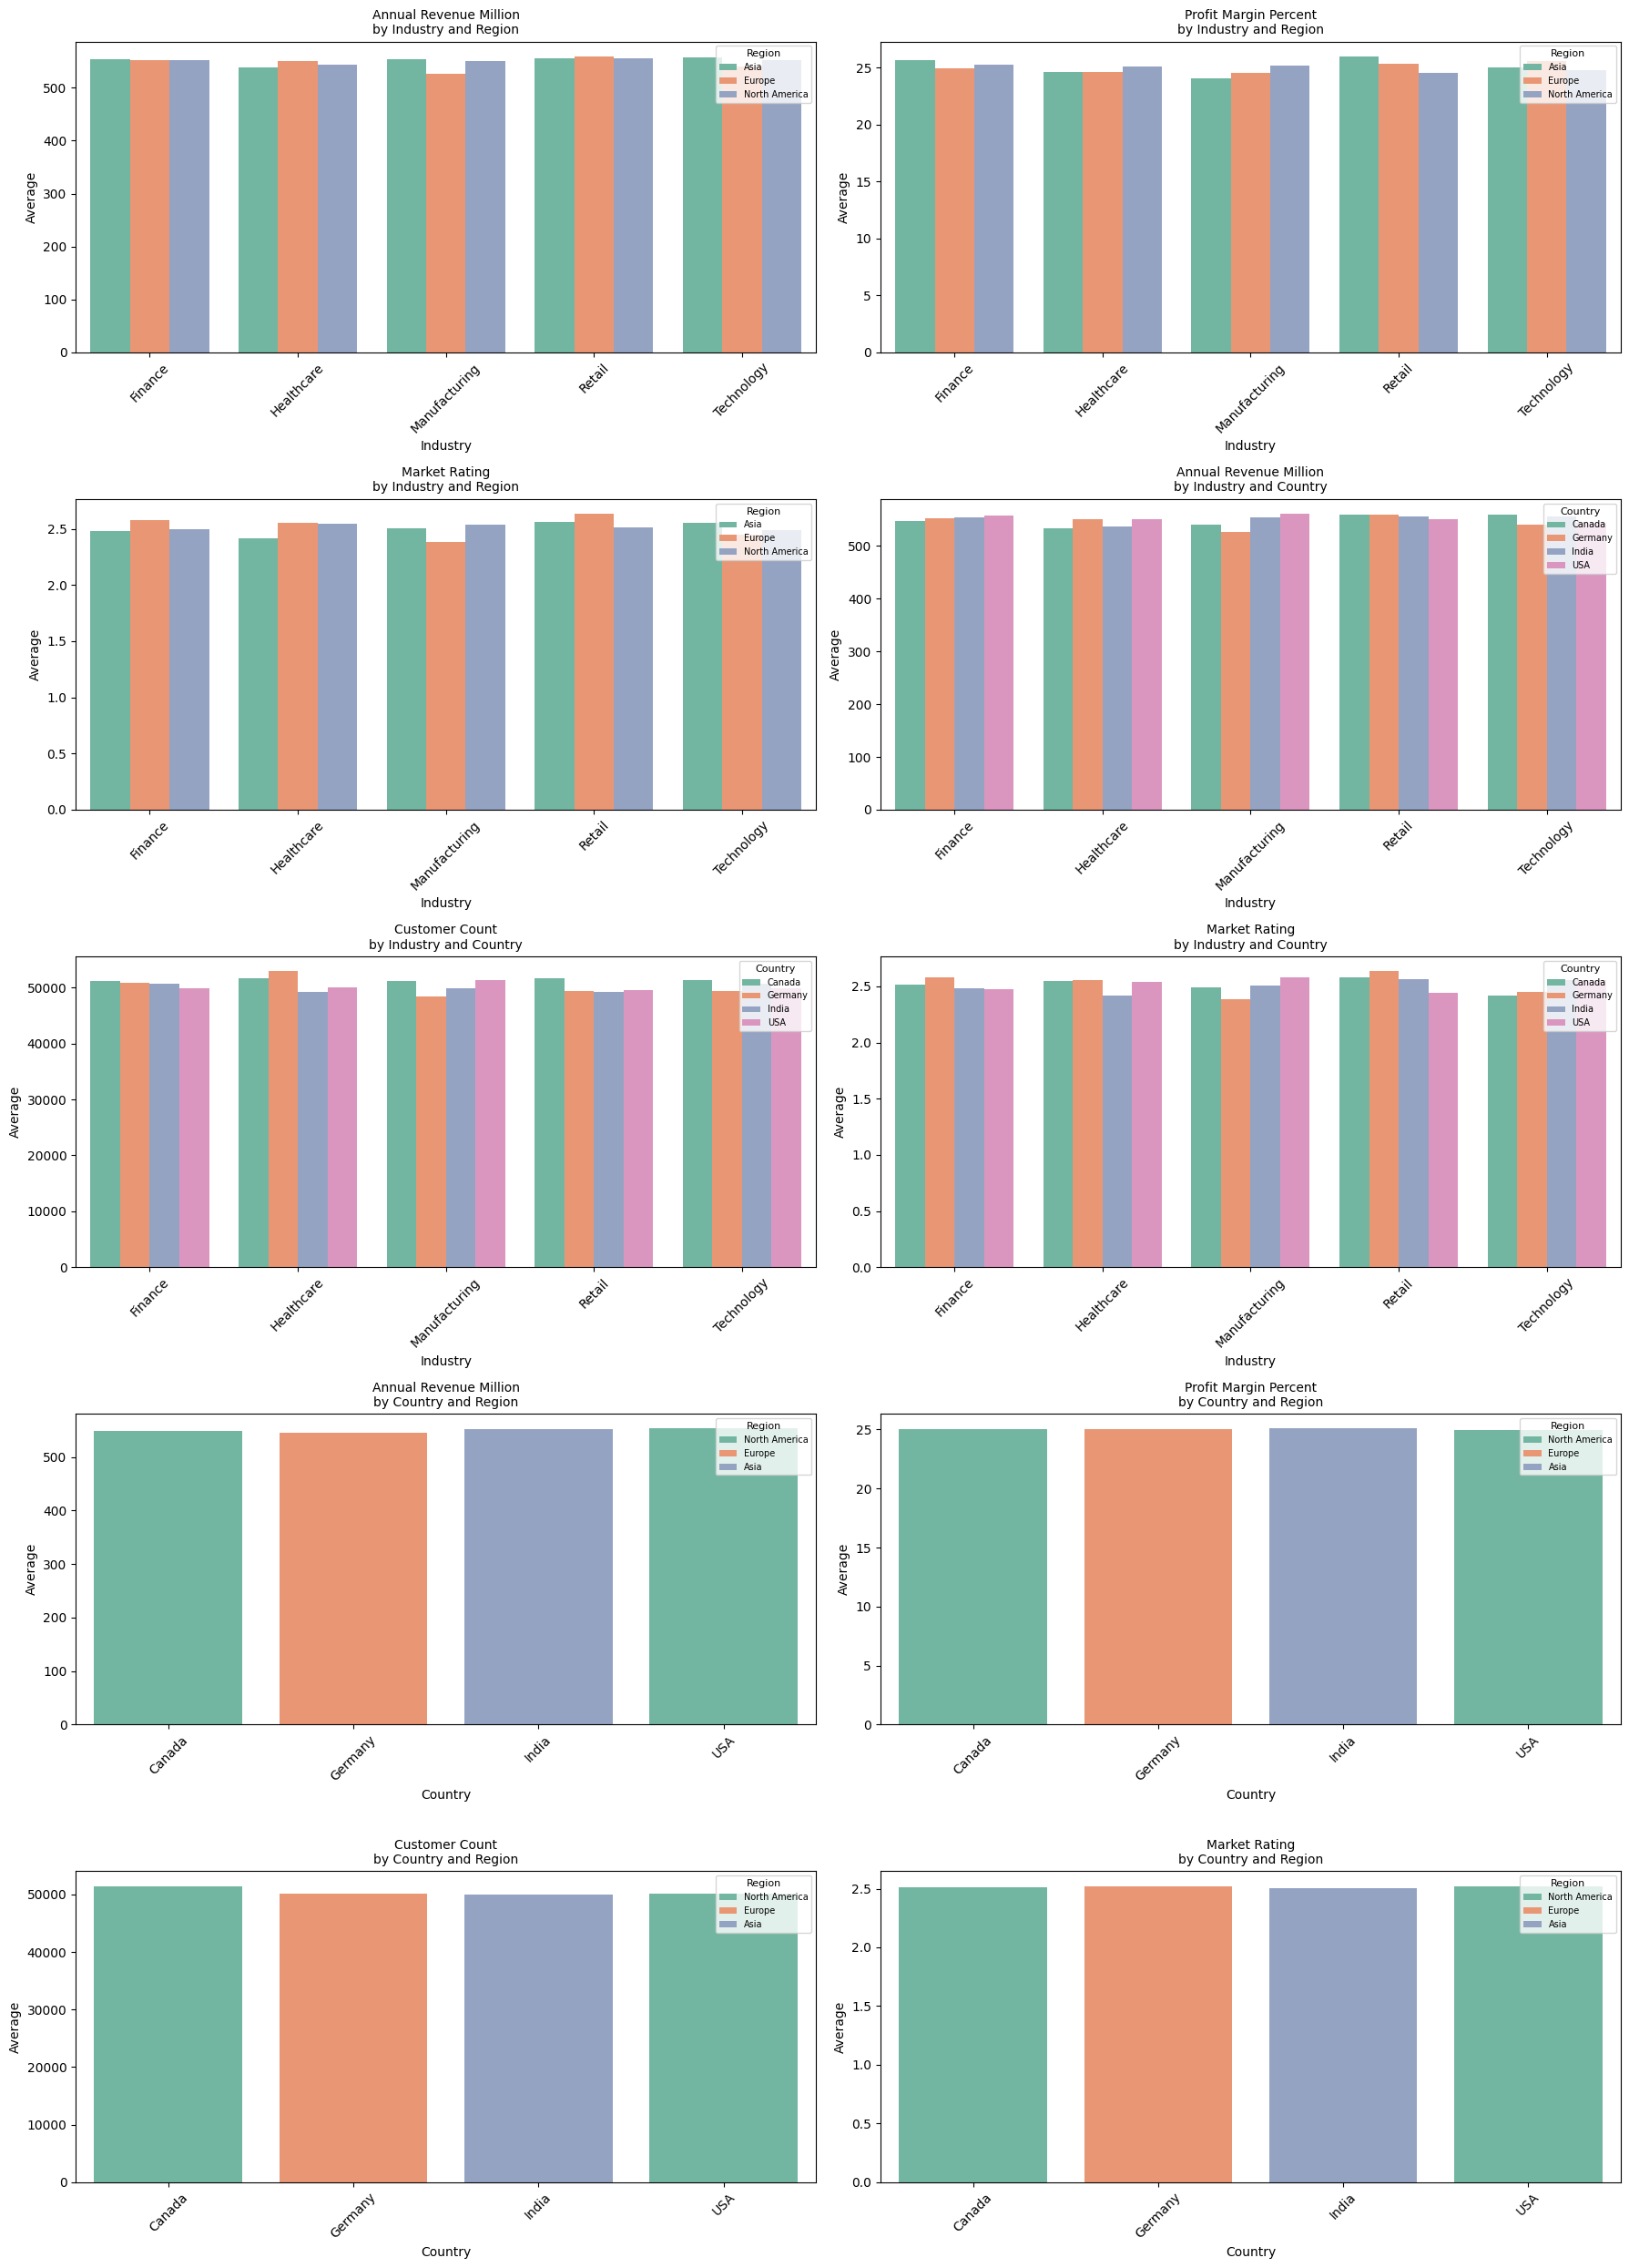

In [45]:
# VISUALIZATION OF MULTIVARIATE ANALYSIS:
# Selected combinations

combinations = [
    ('industry', 'region', 'annual_revenue_million'),
    ('industry', 'region', 'profit_margin_percent'),
    ('industry', 'region', 'market_rating'),

    ('industry', 'country', 'annual_revenue_million'),
    ('industry', 'country', 'customer_count'),
    ('industry', 'country', 'market_rating'),

    ('country', 'region', 'annual_revenue_million'),
    ('country', 'region', 'profit_margin_percent'),
    ('country', 'region', 'customer_count'),
    ('country', 'region', 'market_rating')
]

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(18, 25))

axes = axes.flatten()

for ax, (cat1, cat2, num) in zip(axes, combinations):

    grouped = (df.groupby([cat1, cat2])[num].mean().reset_index())

    sns.barplot(
        data=grouped,
        x=cat1,
        y=num,
        hue=cat2,
        palette='Set2',
        ax=ax)

    ax.set_title(f'{num.replace("_"," ").title()}\nby {cat1.title()} and {cat2.title()}',fontsize=10)

    ax.set_xlabel(cat1.title())
    ax.set_ylabel('Average')

    ax.tick_params(axis='x', rotation=45)

    ax.legend(title=cat2.title(),
        fontsize=7,
        title_fontsize=8,
        loc='best')

plt.tight_layout()
plt.show()

In [44]:
# SKEWNESS AND KURTOSIS INTERPRETATION:

numerical_columns = [
    'employee_count',
    'annual_revenue_million',
    'profit_margin_percent',
    'founded_year',
    'customer_count',
    'market_rating'
]

skew_kurtosis = pd.DataFrame({
    'Skewness': df[numerical_columns].skew(),
    'Kurtosis': df[numerical_columns].kurtosis()
})

print(skew_kurtosis)


                        Skewness  Kurtosis
employee_count          0.002354 -1.187695
annual_revenue_million  0.027341 -1.187059
profit_margin_percent   0.002560 -1.202566
founded_year            0.020605 -1.189609
customer_count         -0.004866 -1.194714
market_rating          -0.020033 -1.205761


**Insights from Skewness and Kurtosis Analysis**  
* <font size ="3"> All variables have skewness values very close to 0 (between -0.02 and 0.03), indicating that the distributions are approximately symmetric with no significant left or right skew.
* The kurtosis values are all around -1.2, which suggests platykurtic distributions. This means the distributions are flatter than a normal distribution and have lighter tails.
* The absence of high positive kurtosis indicates that there are no substantial extreme values or unusual business behaviors in the dataset.
* Revenue, employee count, customer count, profitability, and market ratings appear to be evenly distributed, with no evidence of dominance by a small group of exceptionally large companies.
* Overall, the dataset exhibits balanced and stable distributions, making it suitable for statistical analysis without major concerns regarding skewness or outliers.
* From this, we can conclude that the skewness and kurtosis analysis suggests that the business metrics are generally well-balanced, symmetric, and free from extreme observations. There is little evidence of market concentration, revenue dominance, or unusually influential enterprises within the dataset. </font>

### **7. KEY STATISTICAL FINDINGS:**  
* <font size ="3"> Highly Balanced & Stable Ecosystem- The dataset represents a remarkably uniform and competitive industry of mid-to-large companies. Most firms cluster tightly around ~2,600 employees, ~550M annual revenue, ~25% profit margin, and ~50K customers.
* Revenue distribution is highly symmetrical (skewness ≈ 0.03) with a uniform spread and zero outliers, indicating no extreme dominance by large enterprise
* Clean & Symmetrical Distributions- All numerical variables show near-zero skewness, uniform/platykurtic distributions, and zero outliers (confirmed by IQR and boxplots). This indicates a very stable environment with no extreme performers.
* No Meaningful Relationships: Bivariate analysis reveals virtually zero correlations (all ≈ 0) between key variables. Company size, revenue, profit margin, customer count, and market rating operate almost independently.  
**KEY TAKEAWAY:**  
* All five industries i.e., Finance, Technology, Retail, Manufacturing, Healthcare perform almost identically.
* Perfect balance across geographies- Minimal differences observed between countries (India, Germany, Canada, USA) and regions — no country or region significantly outperforms others.
* Multivariate analysis confirms almost no interactions or strong drivers between variables. 
* Success appears evenly distributed rather than driven by size, sector, age, or location.
* This paints a picture of a mature, fair, and highly competitive corporate landscape with consistent performance across the board.</font>

### **8. FINAL CONCLUSION FROM OVERALL EXPLORATORY DATA ANALYSIS:**  
* <font size ="3"> This comprehensive Exploratory Data Analysis reveals a highly stable, balanced, and competitive industry ecosystem. Companies exhibit remarkably consistent characteristics averaging ~2,600 employees, ~$550 million in annual revenue, ~25% profit margin, and ~50,000 customers with symmetrical distributions, near-zero skewness, platykurtic shapes, and zero outliers across all variables.
* Both bivariate and multivariate analyses confirm virtually no meaningful relationships or interactions between key factors such as company size, revenue, profitability, customer base, industry, country, region, or market rating. The data portrays a true level playing field where success is evenly distributed and not significantly driven by traditional variables like scale, sector, or geography.
* The industry is mature, fair, and highly competitive with minimal performance gaps. This clean, well-balanced dataset offers a reliable foundation for strategic planning, benchmarking, and future predictive modeling.
</font>